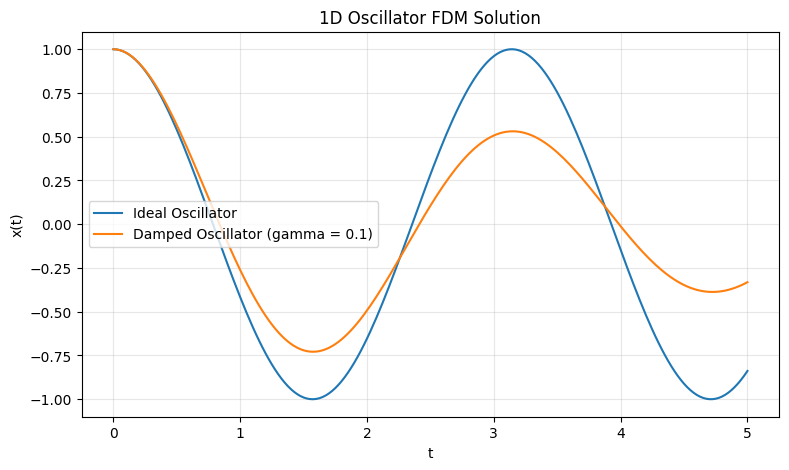

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Problem parameters -----
omega0 = 2.0      # natural frequency
gamma = 0.1     # damping ratio (0=ideal oscillator)
x0 = 1.0          # initial displacement
v0 = 0.0          # initial velocity
tfin = 5.0     # total time

# ----- Discretization -----
Nt = 201                      # number of spatial grid points
t = np.linspace(0, tfin, Nt)
dt = t[1] - t[0]

def oscillator(gamma=0.0):
# ----- Initialize solution -----
  x_FDM = np.zeros(Nt, dtype=np.float64)
  x_FDM[0] = x0

  # Step 1 using Taylor expansion / central difference
  x_FDM[1] = x0 + v0*dt - 0.5*dt**2*(2*gamma*omega0*v0 + omega0**2*x0)

# ----- Time stepping (explicit central difference) -----
  for n in range(1, Nt-1):
      a_n = -2*gamma*omega0*( (x_FDM[n] - x_FDM[n-1])/dt ) - omega0**2*x_FDM[n]
      x_FDM[n+1] = 2*x_FDM[n] - x_FDM[n-1] + dt**2 * a_n
  return x_FDM

x_ideal = oscillator()
x_damped = oscillator(gamma=gamma)

plt.figure(figsize=(9, 5))
plt.plot(t, x_ideal, label = "Ideal Oscillator")
plt.plot(t, x_damped, label = "Damped Oscillator (gamma = 0.1)")
plt.title("1D Oscillator FDM Solution")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----- Create sparse noisy observations (for the PINN) -----
# We'll pick a small set of (x,t) points from the computed "true" solution and add white noise.
rng = np.random.default_rng(0)

n_data = 80                 # number of sparse data points

# Sample random interior points in time and space.
# (We keep x away from boundaries a bit, but you can include them too.)
t_data_idx = rng.integers(0, Nt, size=n_data)
t_data = t[t_data_idx]
x_true_data = x_ideal[t_data_idx] #changes whether we get data from damped or ideal oscillator
noise_std = 0.05
x_noisy_data = x_true_data + noise_std*rng.standard_normal(size=n_data)

Using device: cpu
it=   0 | Loss=1.556e+01 | L_PDE=2.508e+00, L_IC=1.025e+00, L_BC=0.000e+00, L_Data=7.930e-01
it=   1 | Loss=1.243e+01 | L_PDE=7.319e-01, L_IC=1.024e+00, L_BC=0.000e+00, L_Data=6.581e-01
it=   2 | Loss=1.110e+01 | L_PDE=3.524e-02, L_IC=1.013e+00, L_BC=0.000e+00, L_Data=5.994e-01
it=   3 | Loss=1.111e+01 | L_PDE=1.526e-01, L_IC=9.989e-01, L_BC=0.000e+00, L_Data=5.960e-01
it=   4 | Loss=1.157e+01 | L_PDE=5.233e-01, L_IC=9.819e-01, L_BC=0.000e+00, L_Data=6.134e-01
it=   5 | Loss=1.172e+01 | L_PDE=7.205e-01, L_IC=9.580e-01, L_BC=0.000e+00, L_Data=6.212e-01
it=   6 | Loss=1.139e+01 | L_PDE=6.337e-01, L_IC=9.267e-01, L_BC=0.000e+00, L_Data=6.120e-01
it=   7 | Loss=1.078e+01 | L_PDE=3.842e-01, L_IC=8.909e-01, L_BC=0.000e+00, L_Data=5.938e-01
it=   8 | Loss=1.019e+01 | L_PDE=1.430e-01, L_IC=8.540e-01, L_BC=0.000e+00, L_Data=5.772e-01
it=   9 | Loss=9.812e+00 | L_PDE=2.711e-02, L_IC=8.184e-01, L_BC=0.000e+00, L_Data=5.693e-01
it=  50 | Loss=7.373e+00 | L_PDE=1.071e+00, L_IC=2.2

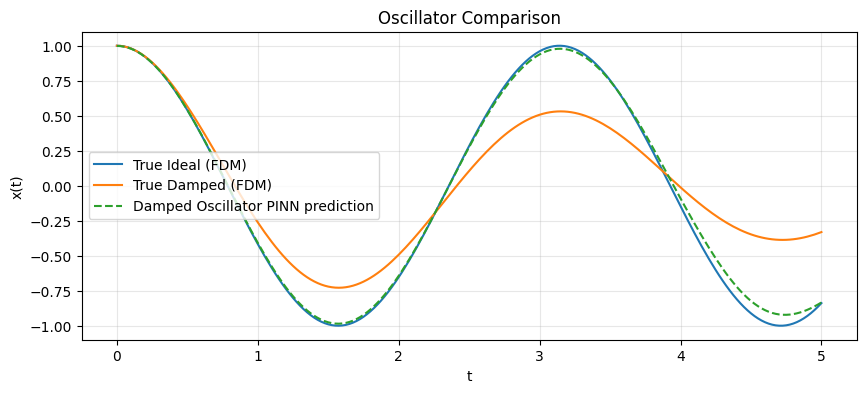

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

omega0 = 2.0
xinit = 1.0
vinit = 0.0
gamma = 0

t_data_t = torch.tensor(t_data.reshape(-1, 1), dtype=torch.float32, device=device)
u_data_t = torch.tensor(x_noisy_data.reshape(-1, 1), dtype=torch.float32, device=device)

# -------------------------
# PINN model: simple fully-connected network
# -------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1,64), nn.Tanh(),
            nn.Linear(64,64), nn.Tanh(),
            nn.Linear(64,1)
        )

        # Xavier initialization helps training stability
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t):
      return self.net(t)

model = PINN()

# -------------------------
# Sampling collocation / IC / BC points
# -------------------------
rng2 = np.random.default_rng(1)

def sample_collocation(Nf, tinit=0.0, tfin=tfin):
    # Generate uniform random numbers between [0,1)
    t_f = torch.tensor(rng2.random((Nf,1)) * (tfin - tinit) + tinit,
                       dtype=torch.float32, device=device)
    t_f.requires_grad_(True)
    return t_f

def sample_initial(N0):
    # Points on initial line t=0
    t_0 = torch.zeros((N0, 1), dtype=torch.float32, device=device, requires_grad = True)
    return t_0

# -------------------------
# Autograd helpers: derivatives
# -------------------------
def grad(outputs, inputs):
    # Compute d(outputs)/d(inputs), same shape as inputs
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True
    )[0]

# -------------------------
# Loss computation
# -------------------------
mse = nn.MSELoss()

def compute_losses(Nf=2000, N0=400, Nb=400):
    t_f = sample_collocation(Nf)
    # 1) PDE residual loss on collocation points
    # Ideal Oscillator:
    xpred = model(t_f)
    x_t = grad(xpred, t_f)
    x_tt = grad(x_t, t_f)

    f = x_tt + 2*gamma*omega0* x_t + omega0**2 * xpred          # PDE residual
    L_pde = torch.mean(f**2)

    # 2) Initial condition loss
    tinit = sample_initial(N0)
    xinit_pred = model(tinit)
    xinit_true = torch.full_like(xinit_pred, xinit)
    xprimeinit_pred = grad(xinit_pred, tinit)
    xprimeinit_true = torch.full_like(xprimeinit_pred, vinit)
    L_ic = mse(xinit_pred, xinit_true) + mse(xprimeinit_pred, xprimeinit_true)

    # 3) Boundary condition loss (none for this problem)
    L_bc = torch.tensor(0.0)

    # 4) Data loss on sparse noisy observations
    u_data_pred = model(t_data_t)
    L_data = mse(u_data_pred, u_data_t)

    return L_pde, L_ic, L_bc, L_data

# -------------------------
# Training loop
# -------------------------
w_pde = 1.0
w_ic = 5.0
w_bc = 1.0
w_data = 10.0

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_iters = 1500

for it in range(n_iters):
    optimizer.zero_grad()
    L_pde, L_ic, L_bc, L_data = compute_losses(Nf=3000, N0=600, Nb=600)
    loss = w_pde*L_pde + w_ic*L_ic + w_data*L_data #L_bc = 0 in this case
    loss.backward()
    optimizer.step()

    # print for iterations
    if it < 10 or (it % 50 == 0):
        print(
            f"it={it:4d} | "
            f"Loss={loss.item():.3e} | "
            f"L_PDE={L_pde.item():.3e}, "
            f"L_IC={L_ic.item():.3e}, "
            f"L_BC={L_bc.item():.3e}, "
            f"L_Data={L_data.item():.3e}"
        )

# -------------------------
# Evaluate and compare to "true" FDM solution at two times
# -------------------------
model.eval()

# Create tensors for PINN predictions
t_full = torch.tensor(t.reshape(-1,1), dtype=torch.float32, device=device)

model.eval()
with torch.no_grad():
    u_pred_1 = model(t_full).cpu().numpy().flatten()
# Plot x_ideal vs PINN
plt.figure(figsize=(10, 4))
plt.plot(t, x_ideal, label="True Ideal (FDM)")
plt.plot(t, x_damped, label="True Damped (FDM)")
plt.plot(t, u_pred_1, "--", label="Damped Oscillator PINN prediction")
plt.title("Oscillator Comparison")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True, alpha=0.3)
plt.legend()